In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [87]:
def convert_csv_to_series(data):
    pd_data=pd.read_csv(data)
    pd_series=pd_data.set_index("Date")
    cols = list(pd_series.columns)
    original_name=cols[0]
    cols[0] = 'Close'
    pd_series.columns = cols
    return pd_series,original_name

def convert_prices_to_log_return(data):
    pd_series,name=convert_csv_to_series(data)[0],convert_csv_to_series(data)[1]
    pd_series["log_returns"]=np.log(pd_series['Close'] / pd_series['Close'].shift(1))
    return pd_series["log_returns"].dropna().to_frame(),name

In [2]:
def estimate_from_data(data, dt=1/252):  
    sigma_square_hat = np.var(data, ddof=1) / dt
    sigma_hat = sigma_square_hat ** (1/2)
    mu_hat = (np.mean(data) / dt) + (sigma_square_hat / 2)  
    return mu_hat, sigma_hat

In [100]:
def simulate_prices(data_price, data_log_return, T, dt=1/252, n_simulations=5):
    np.random.RandomState(42)
    mu_hat, sigma_hat = estimate_from_data(data_log_return, dt=dt)
    drift = (mu_hat - 0.5 * sigma_hat**2) * dt

    predicted = []
    S0 = float(data_price[-1])

    for _ in range(T):
        Z = np.random.normal(size=n_simulations)
        S_next = S0 * np.exp(drift + sigma_hat * np.sqrt(dt) * Z)
        S0 = np.mean(S_next) 
        predicted.append(S0)

    return np.array(predicted)

In [101]:
def final_df_test(test_data,simulated_price):
    test_data["Predicted_value"]=simulated_price
    return test_data

In [102]:
def final_result(data_log_return,data_prices,data_test):
    T=data_test.shape[0]
    
    simulated_price=simulate_prices(data_prices,data_log_return,T)
    return final_df_test(data_test,simulated_price)
    

In [103]:
def plot_predictions(data_test, title=" Stock Price Prediction"):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    dates = pd.to_datetime(data_test["Date"])
    actual = data_test.iloc[:, 1]
    predicted = data_test["Predicted_value"]
    original_name = data_test.columns[1]
    
    ax.plot(dates, actual, label=f"Actual ({original_name})", color="royalblue", linewidth=2, marker='o', markersize=4)
    ax.plot(dates, predicted, label="Predicted (GBM Drift)", color="tomato", linewidth=2, linestyle="--", marker='s', markersize=4)
    
    ax.fill_between(dates, actual, predicted, alpha=0.1, color="gray", label="Prediction Error")
    
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylabel("Price (₹)", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [104]:
sbi=convert_prices_to_log_return("sbi_main.csv")[0].to_numpy()
sbi_prices=convert_csv_to_series("sbi_main.csv")[0].to_numpy()
sbi_test=pd.read_csv("sbi_test.csv")

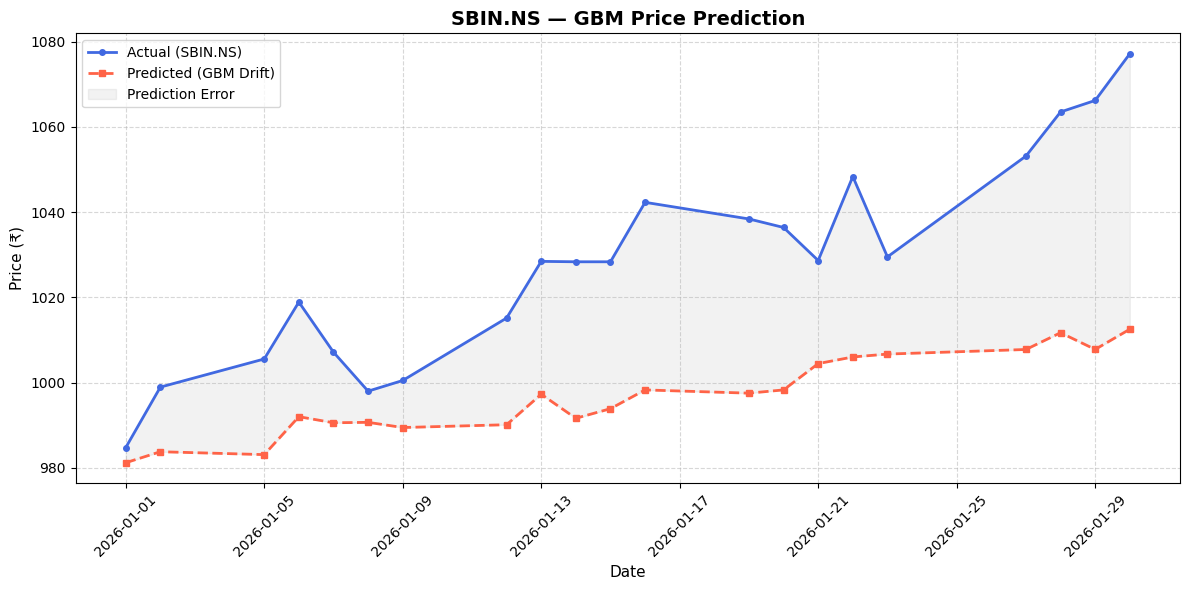

In [105]:
result = final_result(sbi, sbi_prices, sbi_test)
plot_predictions(result, title="SBIN.NS — GBM Price Prediction")